# Image Classification with Neural Networks
## Mulit-Layer Perceptron vs Convolutional Neural Network on CIFAR-10
Adam J Holt

---

The purpose of this notebook is to investigate deep learing models for an image classification task. Specifically, we will design, tune, and compare a Multi-Layer Perceptron (MLP) model with a Convolutional Neural Network (CNN) model. This comparison will be made through evaluating the characteristics and performance of the respective models on the [CIFAR-10 dataset](https://www.cs.toronto.edu/~kriz/cifar.html).

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras

In [2]:
# seed random number generators
from numpy.random import seed
from tensorflow.random import set_seed
seed(5017)
set_seed(5017)

In [ ]:
# mount drive for use with Google Colab
# do not execute if using local gpu
from google.colab import drive
drive.mount('/content/drive')
os.chdir('/content/drive/My Drive/proj1')

## Data Download and Preparation

---

The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images. The classes are:
- Class 0: **airplane**
- Class 1: **automobile**
- Class 2: **bird**
- Class 3: **cat**
- Class 4: **deer**
- Class 5: **dog**
- Class 6: **frog**
- Class 7: **horse**
- Class 8: **ship**
- Class 9: **truck**

The dataset can be downloaded directly from the [TensorFlow library](https://www.tensorflow.org/api_docs/python/tf/keras/datasets/cifar10/load_data).

In [8]:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.cifar10.load_data()

170498071/170498071 [==============================] - 14s 0us/step


Now that we have downloaded the data we can use an 85/15 random split on the training set to form a validation set for the deep learning models we shall develop. Additionally, we will need to stratify the target values in order to maintain a balanced proportion of samples. Before doing so, we must normalize the data so that the sample values fall into the range [0, 1]. Finally, rather that one-hot encoding the target values we can utilize the *sparse categorical crossentropy* loss on vector targets - this affords more efficient execution time during training. Hence we will need to flatten the targets.

In [9]:
from sklearn.model_selection import train_test_split

X_train_full, X_test = X_train_full/255.0, X_test/255.0

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, test_size=0.15, stratify=y_train_full
)

y_train_full = y_train_full.flatten()
y_train = y_train.flatten()
y_valid = y_valid.flatten()
y_test = y_test.flatten()

## Display Sample Images

---

To finalise our preliminary data preparation we can display a random sampling of the images from each of the prepared data-sets, i.e., training, validation, and test sets.

In [10]:
labels = ['airplane', 'automobile', 'bird', 'cat',
          'deer','dog', 'frog', 'horse', 'ship', 'truck']

def display_sample_images(X, y):
    sample_idx = np.random.choice(range(len(X)), size=20, replace=False)
    sample_labels = [labels[y[idx]] for idx in sample_idx]
    sample_images = X[sample_idx]
    rows, cols = 4, 5
    fig=plt.figure(figsize=(cols * 1.2, rows * 1.2))
    for i in range(1, rows*cols + 1):
        fig.add_subplot(rows, cols, i)
        plt.imshow(sample_images[i-1])
        plt.axis('off')
        plt.title(sample_labels[i-1])
    plt.subplots_adjust(wspace=0.2, hspace=0.5)
    plt.show()

#### Training Data Samples

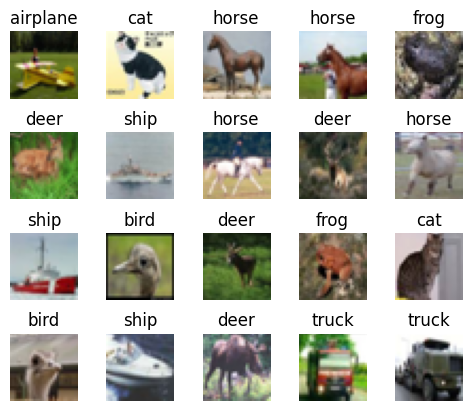

In [11]:
display_sample_images(X_train, y_train)

#### Validation Data Samples

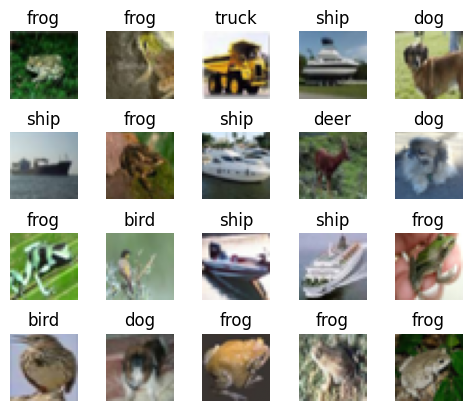

In [12]:
display_sample_images(X_valid, y_valid)

#### Test Data Samples

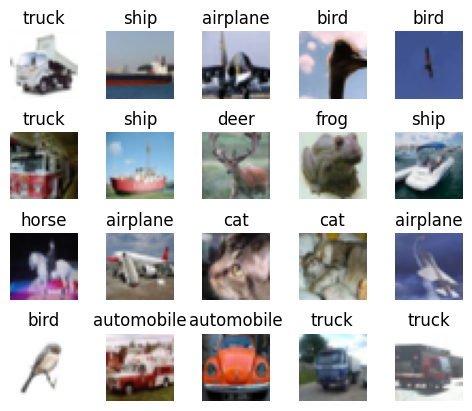

In [13]:
display_sample_images(X_test, y_test)

## MLP & CNN Model Specifications
---

Turning now to the implementation of our deep learning models, we have designed the MLP and CNN model architectures after manually experimenting with various network topologies and hyperparameter settings. Specifically, we trained the models with **stochastic gradient descent** for 100 epochs with early stopping derived from the model accuracy on the validation data in order to determine the optimal hyperparameter values. As indicated earlier, we utilized the **sparse categorical crossentropy** loss function during training. Importantly, before experimenting with various model hyperparameters we established a simple MLP model as a comparitive baseline for evaluating performance improvement. It was found that this baseline MLP model with 2 dense layers of 256 neurons respectively attained validation accuracy of approximately 0.44 by training for 20 epochs (after which validation accuracy failed to improve and the model began to overfit the training data).

#### **MLP Tuning**
---

We will now look at the MLP tuning process step by step. Namely:

- adjusting network topology to 3 dense layers with 1024; 512; and 256 neurons respectively improved validation accuracy over baseline to approximately 0.50 (three layers with a relatively large number of neurons in the first layer appears to be the optimal topology)
- marginal improvements in performance were seen by utilizing different kernel initialization techniques (i.e., He Normal & He Uniform) but these techniques were undifferentiated with respect to validation accuracy and loss metrics (i.e., they each offered small absolute improvements in validation accuracy of approximately 0.5 percentage points)
- the addition of intra layer dropout also effected validation performance, i.e., high dropout rates negatively effected validation accuracy but a low dropout rate of 0.10 provided marginal imporvements to validation accuracy (i.e., approximately 0.5 absolute percentage points)

This network architecture results in an MLP model with:
- Total parameters: 3805450
- Trainable parameters: 3805450
- Non-trainable parameters: 0

Finally, significant improvement of validation accuracy and loss was made through modulating the learning rate of the training process. Two learning rate mechanisms were tested:

- stochastic gradient descent with simple time based decay where $$decay\ rate = {learning\ rate \over epochs}$$
- exponential decay through learning rate scheduling where
$$learning\ rate = initial\ learning\ rate \times e^{-decay\ rate \times epoch}$$

While both techniques improved validation performance it was found that the exponential decay schedule was superior and had the effect of faster convergence. The resulting MLP model consitently attained a validation accuracy of approximately 0.55.

#### **CNN Tuning**
---

We experimented with CNN designs with 2 to 3 convolutional layers and a pooling layer between consecutive convolutional layers in conjuction with 1 to 2 fully connected layers and batch normalisation layers to help control the numerical values of the network weights. Specifically, 3 convolution layers with $3 \times 3$ kernels each with 64; 128; and 256 filter units respectively with 2 pooling layers of size 2 and a single densely connected layer of 256 units was found to be optimal in our setting. ReLU was used as the activation function and the resulting CNN model achieved aproximately 0.74 validation accuracy during training. To arrive at this network architecture we experimented with various settings. Namely:

- kernel sizes of $3 \times 3$ and $5 \times 5$ were tested with the smaller pixel coverage being similar to results produced by the larger pixel coverage
- 3 filters (i.e., 64; 128; and 256 respectively) consistently produced validation accuracy above 0.73 whilst 2 filters (i.e., 64; and 128 respectively) were not as consistent
- ReLU and Tanh activation functions performed similarly on the validation data during training (i.e., each in the 0.73 - 0.74 accuracy range)

This network architecture results in a CNN model with:
- Total params: 1423242
- Trainable params: 1422730
- Non-trainable params: 512

Finally, the optimal learning rate (i.e., exponential decay scheduling) from the MLP model was utilized also for the CNN model in addition to the He Normal kernel initialization but the dropout layers were found to be extraneous and were therefore not utilized in the CNN model.

#### **Tuning Results**
---

The resulting MLP and CNN models produced the following (approximate) results on the test data:

- MLP **loss**: 1.2  |  MLP **accuracy**: 0.55
- CNN **loss**: 1.3  |  CNN **accuracy**: 0.74

## Model Implementation & Training
---

In the following block of code we implement the MLP and CNN models as described above. Furthermore, we have designed the program logic of the training process such that the following two options are available to test the models:

- train the network from scratch for 100 epochs using the optimal hyperparameter values, saving the resultant model to the current directory or;
- load the trained model from the current directory if it is present and train it for just 1 more epoch


In [14]:
# exponential decay learning rate
def exp_decay(epoch):
  init_lrate = 0.1
  decay_rate = 0.1
  lrate = init_lrate * np.exp(-decay_rate * epoch)
  return lrate


# early stopping & learning rate schedule callbacks
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=10),
    keras.callbacks.LearningRateScheduler(exp_decay)
]


# make the MLP model to specification
def make_mlp():
  mlp = keras.Sequential([
    keras.layers.Flatten(input_shape=X_train.shape[1:]),
    keras.layers.Dense(units=1024, activation='relu', kernel_initializer='he_normal'),
    keras.layers.Dropout(0.1),
    keras.layers.Dense(units=512, activation='relu', kernel_initializer='he_normal'),
    keras.layers.Dropout(0.1),
    keras.layers.Dense(units=256, activation='relu', kernel_initializer='he_normal'),
    keras.layers.Dropout(0.1),
    keras.layers.Dense(units=10, activation='softmax'),
  ])
  mlp.compile(
    optimizer='sgd',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
  )
  return mlp


# make the CNN model to specification
def make_cnn():
  cnn = keras.Sequential([
    keras.layers.InputLayer(input_shape=X_train.shape[1:]),
    keras.layers.Conv2D(filters=64, kernel_size=3, activation='relu', kernel_initializer='he_normal'),
    keras.layers.MaxPooling2D(pool_size=2),
    keras.layers.Conv2D(filters=128, kernel_size=3, activation='relu', kernel_initializer='he_normal'),
    keras.layers.MaxPooling2D(pool_size=2),
    keras.layers.Conv2D(filters=256, kernel_size=3, activation='relu', kernel_initializer='he_normal'),
    keras.layers.BatchNormalization(),
    keras.layers.Flatten(),
    keras.layers.Dense(units=256, activation='relu'),
    keras.layers.Dense(units=10, activation='softmax')
  ])
  cnn.compile(
    optimizer='sgd',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
  )
  return cnn


# train a model from scratch for 100 epochs
def train_from_scratch(model):
  start = time.time()
  hist = model.fit(
    X_train, y_train, epochs=100,
    callbacks=callbacks,
    validation_data=(X_valid, y_valid)
  )
  finish = time.time()
  training_time = (finish - start) / 60
  return model, training_time, hist


# load and train existing model for 1 more epoch
def load_train_existing(model_path):
  model = keras.models.load_model(model_path)
  model.summary()
  model.fit(
    X_train, y_train, epochs=1,
    validation_data=(X_valid, y_valid)
  )
  return model


# make and train the model
def make_train_model(model_type):
  if model_type == 'mlp':
    mlp = make_mlp()
    mlp.summary()
    mlp, mlp_time, mlp_hist = train_from_scratch(mlp)
    return mlp, mlp_time, mlp_hist
  elif model_type == 'cnn':
    cnn = make_cnn()
    cnn.summary()
    cnn, cnn_time, cnn_hist = train_from_scratch(cnn)
    return cnn, cnn_time, cnn_hist
  else:
    print('error: invalid model type')


# display training history (learning curves)
def display_training_history(hist, model_type):
  plt.figure(figsize=(10,4))
  # loss
  plt.subplot(1,2,1)
  plt.plot(hist.history['loss'])
  plt.plot(hist.history['val_loss'])
  plt.legend(['training', 'validation'])
  plt.title(model_type + ' Loss')
  # accuracy
  plt.subplot(1,2,2)
  plt.plot(hist.history['accuracy'])
  plt.plot(hist.history['val_accuracy'])
  plt.legend(['training', 'validation'])
  plt.title(model_type + ' Accuracy')
  plt.tight_layout()
  plt.show();


## Execute MLP Build/Train Process
---

With the model architecture specified and program logic defined we a ready to execute the model building and training process. As indicated earlier, if a pretrained model is present in the current working directory it will be loaded and trainied for 1 more epoch. Otherwise, the model will be built from scratch and trained for 100 epochs. Upon execution, a summary of the model architecture will be displayed then the training will commence. Finally, the training time will be displayed and the model saved (if required) after which the model learning curves will be displayed (if required) and the model fit once more to the full training dataset before predictions can be made on a small random sample of the test data.

In [15]:
model_path = 'Holt_Adam-MLP'
model_type = 'mlp'
trained_from_scratch_mlp = False

if os.path.exists(model_path):
  mlp = load_train_existing(model_path)
else:
  try:
    mlp, mlp_time, mlp_hist = make_train_model(model_type)
    print('Training time:', round(mlp_time, 2), 'minutes')
    mlp.save(model_path, save_format='tf')
    print('Model saved:', model_path)
    trained_from_scratch_mlp = True
  except:
    print('model_type: {mlp, cnn}')


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 3072)              0         
                                                                 
 dense (Dense)               (None, 1024)              3146752   
                                                                 
 dropout (Dropout)           (None, 1024)              0         
                                                                 
 dense_1 (Dense)             (None, 512)               524800    
                                                                 
 dropout_1 (Dropout)         (None, 512)               0         
                                                                 
 dense_2 (Dense)             (None, 256)               131328    
                                                                 
 dropout_2 (Dropout)         (None, 256)               0

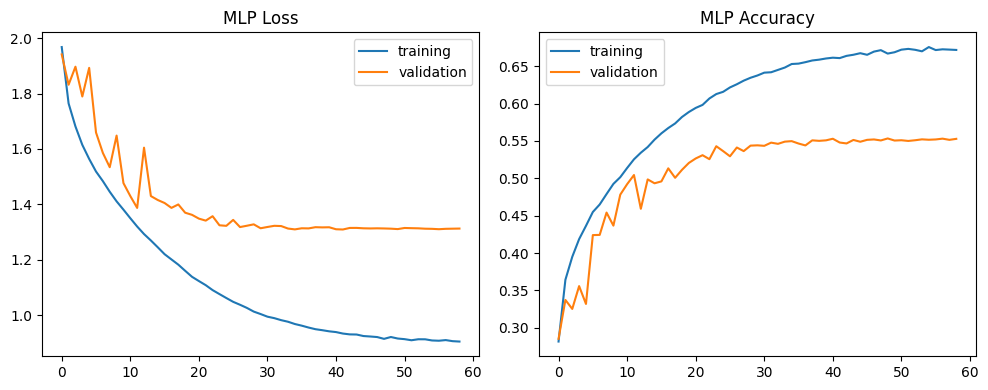

In [16]:
# display training history - if trained from scratch
if trained_from_scratch_mlp:
  display_training_history(mlp_hist, 'MLP')
else:
  print('No training history to display')

In [17]:
# fit the full training data
mlp.fit(X_train_full, y_train_full)

1563/1563 [==============================] - 5s 3ms/step - loss: 0.9800 - accuracy: 0.6544


In [18]:
# make predictions on small sample of test set
rand_sample = np.random.choice(range(len(X_test)), size=10, replace=False)
sample_predictions = np.argmax(mlp.predict(X_test[rand_sample]), axis=1)
[labels[idx] for idx in sample_predictions]

1/1 [==============================] - 0s 92ms/step


['bird',
 'bird',
 'automobile',
 'frog',
 'horse',
 'deer',
 'horse',
 'automobile',
 'ship',
 'automobile']

In [19]:
# loss, accuracy - test set
mlp_loss, mlp_acc = mlp.evaluate(X_test, y_test)
print('MLP loss:', round(mlp_loss, 4), ' | ', 'MLP Accuracy:', round(mlp_acc, 4))

313/313 [==============================] - 1s 2ms/step - loss: 1.2789 - accuracy: 0.5521
MLP loss: 1.2789  |  MLP Accuracy: 0.5521


## Execute CNN Build/Train Process
---
The same process as above in the MLP case is executed here for the CNN model.

In [27]:
model_path = 'Holt_Adam-CNN'
model_type = 'cnn'
trained_from_scratch_cnn = False

if os.path.exists(model_path):
  cnn = load_train_existing(model_path)
else:
  try:
    cnn, cnn_time, cnn_hist = make_train_model(model_type)
    print('Training time:', round(cnn_time, 2), 'minutes')
    cnn.save(model_path, save_format='tf')
    print('Model saved:', model_path)
    trained_from_scratch_cnn = True
  except:
    print('model_type: {mlp, cnn}')


Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 30, 30, 64)        1792      
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 15, 15, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_4 (Conv2D)           (None, 13, 13, 128)       73856     
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 6, 6, 128)         0         
 g2D)                                                            
                                                                 
 conv2d_5 (Conv2D)           (None, 4, 4, 256)         295168    
                                                                 
 batch_normalization_1 (Bat  (None, 4, 4, 256)        

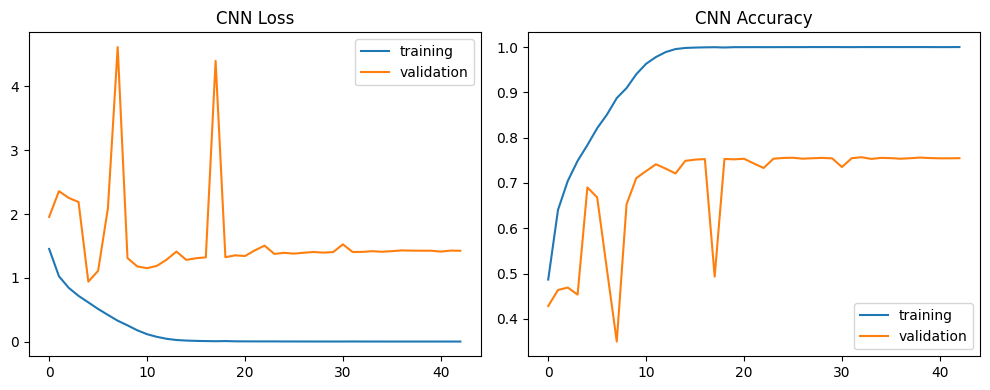

In [28]:
# display training history - if trained from scratch
if trained_from_scratch_cnn:
  display_training_history(cnn_hist, 'CNN')
else:
  print('No training history to display')

In [29]:
# fit the full training data
cnn.fit(X_train_full, y_train_full)

1563/1563 [==============================] - 6s 4ms/step - loss: 0.2168 - accuracy: 0.9613


In [30]:
# make predictions on small sample of test set
rand_sample = np.random.choice(range(len(X_test)), size=10, replace=False)
sample_predictions = np.argmax(cnn.predict(X_test[rand_sample]), axis=1)
[labels[idx] for idx in sample_predictions]

1/1 [==============================] - 0s 84ms/step


['frog',
 'horse',
 'dog',
 'ship',
 'ship',
 'truck',
 'bird',
 'ship',
 'ship',
 'airplane']

In [31]:
# loss, accuracy - test set
cnn_loss, cnn_acc = cnn.evaluate(X_test, y_test)
print('CNN loss:', round(cnn_loss, 4), ' | ', 'CNN Accuracy:', round(cnn_acc, 4))

313/313 [==============================] - 1s 2ms/step - loss: 1.3705 - accuracy: 0.7463
CNN loss: 1.3705  |  CNN Accuracy: 0.7463


## Evaluate & Compare Models
---
We are now able to evaluate the MLP and CNN models and compare the respective performance. For our comparison we shall investigate several aspects of the models and the training and testing results. Specifically, we will look at:

- model complexity and computation time
- model performance metrics (accuracy, F1-score, and precision per class)
- confusion matrices on both training and testing data

**N.B.** Reproducibility of results is dependent on various factors, i.e., seeding the random number generators etc. Importantly, in our case the model results and training times are dependent on the runtime environment (GPU, CPU). Hence, whilst the numeric results are stable they will vary by small amounts.

### Model Complexity & Computation Time
---
We can use the number of trainable parameters as a proxy measure for the inherent complexity of the model. Here we see that the MLP model has:

- Trainable parameters: 3805450
- Non-trainable parameters: 0

Whilst the CNN model has:
- Trainable params: 1422730
- Non-trainable params: 512

From these model architectures we can see that the MLP model is approximately 2.6 times larger (i.e., more complex). This complexity is somewhat evident in the training process whereby the MLP model is marginally slower to converge to an optimal validation accuracy, i.e., training time is typically in the range of approximately 4 to 8 minutes for either model but the CNN model is usually faster to achieve it's best validation accuracy which is approximately 0.74 as compared to the MLP which is approximately 0.55 (see learning curves above). These considerations alone suggest that the CNN model is superior to the MLP model. Take into account also the nature of the data - images - and it is difficult to see a circumstance for which the MLP model would be preferred for the classification task at hand.

**N.B.** It is important to note that due to the stochastic (i.e., pseudorandom) nature of the optimization algorithm (i.e., stochastic gradient descent) the time taken for convergence during training can be variable. Additionally, training times are also dependent on the early stopping parameterization (i.e., it was found that a patience of 10 consistently gave the best validation accuracy for both models).

### Model Performance Metrics
---
Turning now to the performance metrics: accuracy, F1 score, and precision per class. First we will evaluate the models on the training and test data - generating predictions - after which we can collect the various metrics of interest and display them in a table format (ie., data-frame). Next we will look at each of the models precision per class on the training and test data.

**N.B.** Numeric results will vary upon re-training of models and runtime environment.

In [32]:
from sklearn.metrics import classification_report

In [33]:
# generate model predictions - training and test data
mlp_predictions_train = np.argmax(mlp.predict(X_train_full), axis=1)
cnn_predictions_train = np.argmax(cnn.predict(X_train_full), axis=1)
mlp_predictions_test = np.argmax(mlp.predict(X_test), axis=1)
cnn_predictions_test = np.argmax(cnn.predict(X_test), axis=1)

313/313 [==============================] - 1s 2ms/step


In [34]:
# collect the appropriate metrics - training and test data
mlp_metrics_train = classification_report(y_train_full, mlp_predictions_train, target_names=labels, output_dict=True)
cnn_metrics_train = classification_report(y_train_full, cnn_predictions_train, target_names=labels, output_dict=True)
mlp_metrics_test = classification_report(y_test, mlp_predictions_test, target_names=labels, output_dict=True)
cnn_metrics_test = classification_report(y_test, cnn_predictions_test, target_names=labels, output_dict=True)

# organise metrics
metrics = pd.DataFrame({
    'metric': ['accuracy', 'precision', 'f1-score'],
    'mlp_train': [mlp_metrics_train['accuracy']] + [mlp_metrics_train['macro avg'][key] for key in ['precision', 'f1-score']],
    'cnn_train': [cnn_metrics_train['accuracy']] + [cnn_metrics_train['macro avg'][key] for key in ['precision', 'f1-score']],
    'mlp_test': [mlp_metrics_test['accuracy']] + [mlp_metrics_test['macro avg'][key] for key in ['precision', 'f1-score']],
    'cnn_test': [cnn_metrics_test['accuracy']] + [cnn_metrics_test['macro avg'][key] for key in ['precision', 'f1-score']]
}).set_index('metric')

#### Performance Metrics on Training & Test Data

In the table below we see that the are all comparitively similar for the respective models. In particular, accuracy, precision, and f1-score are all approximately 0.71 for the MLP model evaluated on the training data whereas these measures all similarly decline to approximately 0.55 with respect to the test data. In a similar way, albeit from a much higher base, the CNN model attains approximately 0.97 across all metrics on the training data whilst declining to approximately 0.74 across all metrics on the test data. These metrics represent relative declines of approximately 21% and 23% from training to test data for MLP and CNN models respectively. Of course, the absolute accuracy of 75% on the test data for the CNN model is of greatest importance as this is the gauage upon wich the model would most likely be evaluated if it were deployed on out of sample data. From these considerations we determine that the CNN model has better performance than the MLP model.

In [35]:
metrics

,mlp_train,cnn_train,mlp_test,cnn_test
metric,,,,
accuracy,0.711460,0.966660,0.552100,0.746300
precision,0.710182,0.966670,0.549501,0.747990
f1-score,0.709722,0.966659,0.549768,0.746796


#### Precision per Class on Training Data

Looking now at model precision per class. Firstly, from the table below we can see that with respect to the training data the CNN model again has vastly better precision for all classes. Indeed, the lowest precision attained is consistently above 0.90. Very high precision of approximately 0.97 - 0.98 is attained for the **truck** and **automobile** classes (also **frog**). Regarding the MLP model, it appears that the precision is best for artificial classes, i.e., **airplane**; **truck**; **ship**; **automobile**. Interestingly, the greatest differences in precision between the models occurs on animal classes, i.e., **cat**; **deer**; **bird**; **bird**; **frog**; **dog**.

In [36]:
precision_per_class_train = pd.DataFrame({
    'class': labels,
    'mlp_precision': [mlp_metrics_train[label]['precision'] for label in labels],
    'cnn_precision': [cnn_metrics_train[label]['precision'] for label in labels],
    'precision_difference': [cnn_metrics_train[label]['precision'] - mlp_metrics_train[label]['precision'] for label in labels],
}).set_index('class')
precision_per_class_train.sort_values(by='precision_difference', ascending=False)

,mlp_precision,cnn_precision,precision_difference
class,,,
cat,0.597763,0.941879,0.344116
deer,0.618423,0.962533,0.344109
bird,0.630196,0.962955,0.332759
frog,0.688375,0.975737,0.287362
dog,0.664870,0.950758,0.285888
airplane,0.739403,0.970146,0.230744
truck,0.767899,0.974251,0.206352
ship,0.780856,0.978821,0.197965
horse,0.791396,0.969432,0.178036


#### Precision per Class on Test Data
In contrast with the precision per class on the training data, in the case of the test data it appears that the **truck** class is now among those classes with greatest precision difference between the models whilst the animal classes (**frog**, **deer**, **bird** etc.) remain with relatively large differences between the models. As in the training data case, the models have high relative precision on artificial classes. Interestingly, the MLP model has maintained a relatively high precision for the **horse** class between training and test which is comparible to the artificial classes (i.e., **airplane**, **ship**, **automobile**). Again, the CNN model has superior overall precision per class on the test data.

In [37]:
precision_per_class_test = pd.DataFrame({
    'class': labels,
    'mlp_precision': [mlp_metrics_test[label]['precision'] for label in labels],
    'cnn_precision': [cnn_metrics_test[label]['precision'] for label in labels],
    'precision_difference': [cnn_metrics_test[label]['precision'] - mlp_metrics_test[label]['precision'] for label in labels],
}).set_index('class')
precision_per_class_test.sort_values(by='precision_difference', ascending=False)

,mlp_precision,cnn_precision,precision_difference
class,,,
frog,0.548986,0.816162,0.267175
deer,0.456583,0.717949,0.261366
bird,0.452891,0.680131,0.227240
truck,0.601578,0.809852,0.208274
ship,0.647822,0.826214,0.178392
automobile,0.673216,0.850449,0.177233
airplane,0.622156,0.794634,0.172477
horse,0.640124,0.807692,0.167568
dog,0.472749,0.638577,0.165828


### Confusion Matrices
---
Continuing our model comparison we shall now investigate the classification results by analysing the confusion matrices for the training and test data.

In [38]:
from sklearn.metrics import confusion_matrix

In [39]:
def display_confusion_matrix(targets, predictions, labels, title):
  conf_mtx = pd.DataFrame(
      confusion_matrix(targets, predictions),
      index=labels, columns=labels
  )
  sns.heatmap(conf_mtx, annot=True, cbar=None, cmap="Blues", fmt='d')
  plt.title(title)
  plt.ylabel("True Class"), plt.xlabel("Predicted Class")

#### Confusion Matrices - Training Data
Firstly, it is clear from the confusion matrices below that the MLP model makes significantly more classification errors on the training data than does the CNN model. In particular, we see that the MLP mistakes **deers** with **birds**; **dogs** with **cats**; and **frog** with **cats** or **birds** with high frequency. Similarly, **automobiles** are confused with **trucks** and **ships** with **airplanes** with realativley high frequency. Comparitively little missclassifications are present on the training data for the CNN model but it does appear to mistake **dogs** with **cats** and **cats** with dogs with greater frequency than othe classes.

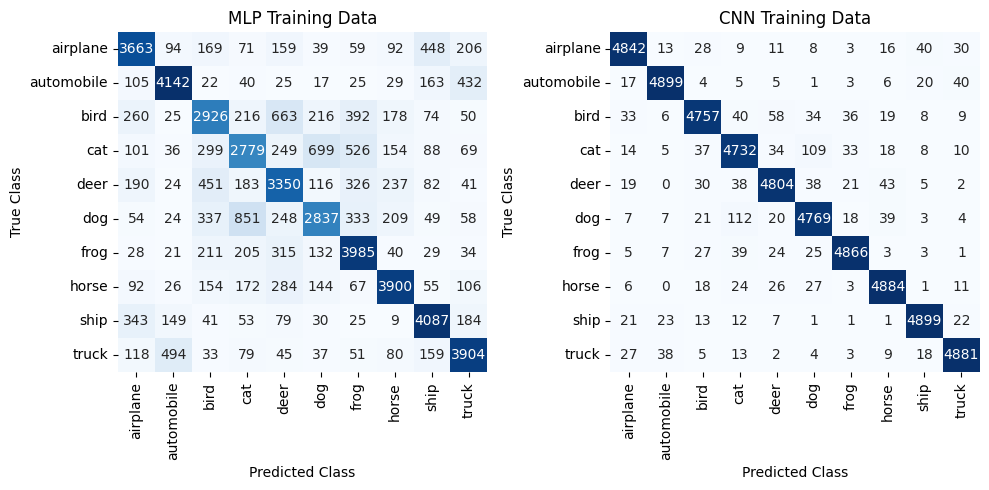

In [40]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
display_confusion_matrix(y_train_full, mlp_predictions_train, labels, 'MLP Training Data')
plt.subplot(1,2,2)
display_confusion_matrix(y_train_full, cnn_predictions_train, labels, 'CNN Training Data')
plt.tight_layout();

#### Confusion Matrices - Test Data

We can see that on the test data similar patterns of missclassification are present as with the training data. Namely, the **automobile**; **airplane**; and **truck** classes are realatively commonly confused with one-another and the animal classes are frequently missclassified (particularly in the MLP model predictions). It is clear that the CNN model is better suited to determining subtle differences in the animal classes but it is interesting to note that in the case of the arguably most similar classes (i.e., **dogs** and **cats**) the CNN model does not significantly outperform the MLP model. Perhaps a more fine tuned convolution architecture is required for performance gains in this classification instance to be seen. Nonetheless, the CNN model is clearly better suited to the image classifciation task than is the MLP model.

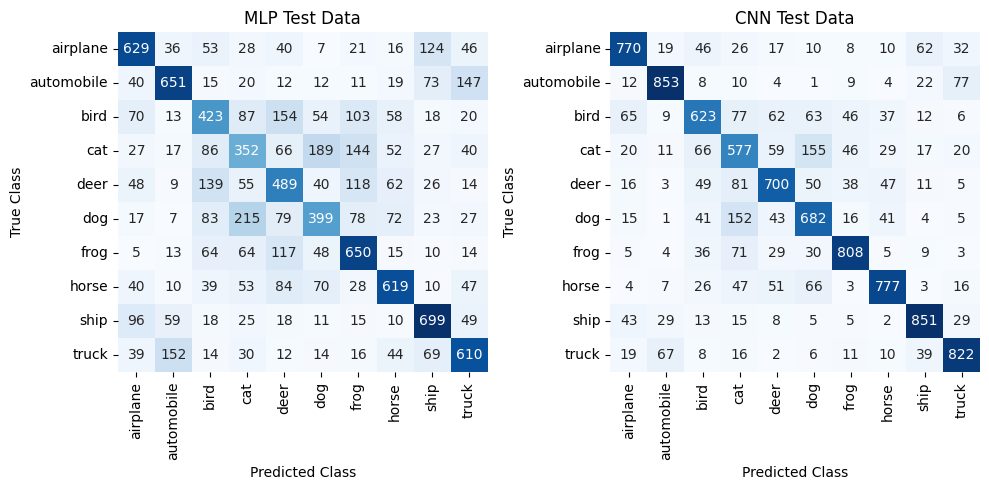

In [41]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
display_confusion_matrix(y_test, mlp_predictions_test, labels, 'MLP Test Data')
plt.subplot(1,2,2)
display_confusion_matrix(y_test, cnn_predictions_test, labels, 'CNN Test Data')
plt.tight_layout();

#### Sample Image Displays

To conclude our investigation of the MLP and CNN models we shall display a sample of the images from the test data that:

- MLP correctly classifies
- CNN correctly classifies
- MLP incorrectly classifies
- CNN incorrectly classifies
- MLP correctly classifies but CNN incorrectly classifies
- CNN correctly classifies but MLP incorreclty classifies

It is interesting to see in the sample images below some of the more infrequent mistakes that are made by the models such as confusing artificial objects such as **airplanes** and **autombobiles** with animals such as **horses** and **deers**. This again highlights that whilst the CNN model is superior to the MLP on all metrics it is still capable of making mistakes of classification in ways that seem obviously incorrect to human observers.

In [42]:
correct_mlp = mlp_predictions_test == y_test
correct_cnn = cnn_predictions_test == y_test
incorrect_mlp = mlp_predictions_test != y_test
incorrect_cnn = cnn_predictions_test != y_test
mlp_correct_cnn_incorrect = np.setdiff1d(np.where(correct_mlp), np.where(correct_cnn))
cnn_correct_mlp_incorrect = np.setdiff1d(np.where(correct_cnn), np.where(correct_mlp))

**Correct MLP Classifications**

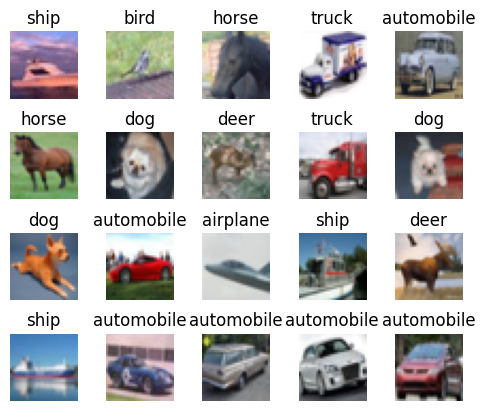

In [43]:
# Correct MLP classifications
display_sample_images(X_test[correct_mlp, ], mlp_predictions_test[correct_mlp])

**Correct CNN Classifications**

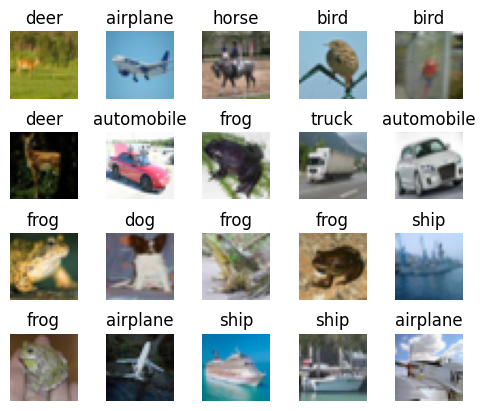

In [44]:
# Correct CNN classifications
display_sample_images(X_test[correct_cnn, ], cnn_predictions_test[correct_cnn])

**Incorrect MLP Classifications**

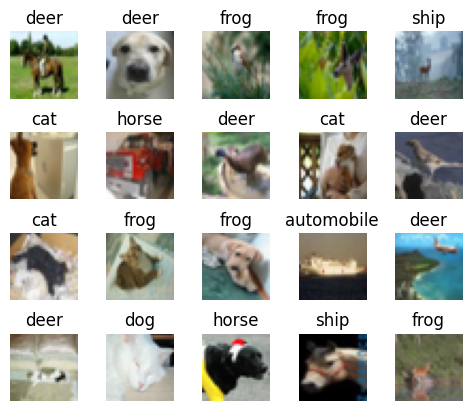

In [45]:
# Incorrect MLP classifications
display_sample_images(X_test[incorrect_mlp, ], mlp_predictions_test[incorrect_mlp])

**Incorrect CNN Classifications**

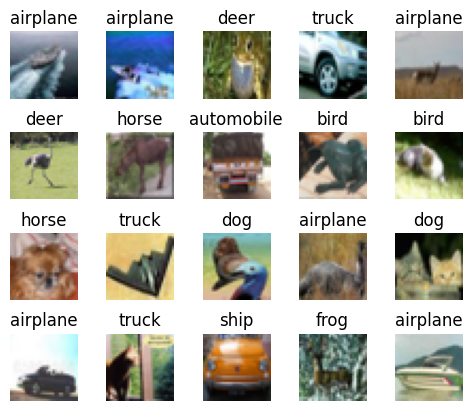

In [46]:
# Incorrect CNN classifications
display_sample_images(X_test[incorrect_cnn, ], cnn_predictions_test[incorrect_cnn])

**Correct MLP Classifications - Incorrect CNN classifications**

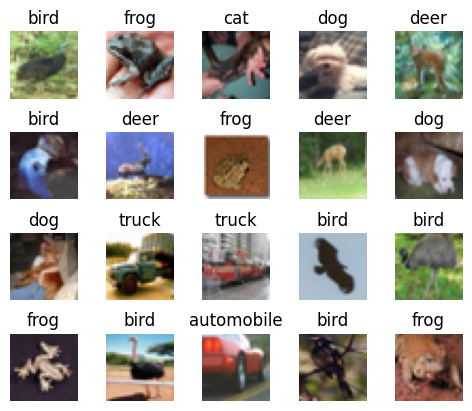

In [47]:
# MLP correct CNN incorrect
display_sample_images(X_test[mlp_correct_cnn_incorrect, ], y_test[mlp_correct_cnn_incorrect])

**Correct CNN Classifications - Incorrect MLP Classifications**

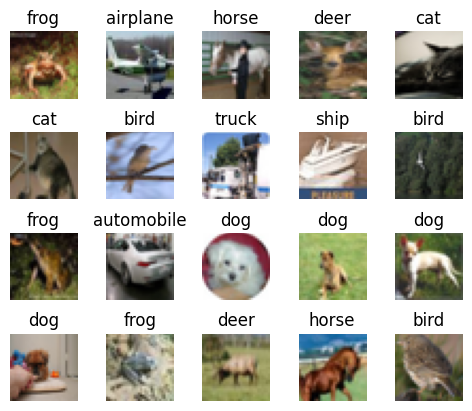

In [48]:
# CNN correct MLP incorrect
display_sample_images(X_test[cnn_correct_mlp_incorrect, ], y_test[cnn_correct_mlp_incorrect])

## Summary and Conclusion
---

In this notebook we investigated MLP and CNN deep learning models for image classification on the CIFAR-10 dataset. By experimenting with various network architectures and parameterizations we found that the optimal MLP and CNN models attained accuracy on the test data of approximately 0.55 and 0.74 respectively. Through our examination of these models we were able to conlude that in this setting the CNN model is superior to the MLP model with respect to all performance metrics. Finally, although the CNN model represented a significant improvement over the baseline model and the optimal MLP model, the model is still capable of making mistakes of classification in ways that seem obviously incorrect to human observers.